In [2]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importar datos student_model_processed
df = pd.read_csv('C:/Users/fabia/Documents/GitHub/Prediccion-rendimiento-academico/DATA/PROCESSED/student_model_processed.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 35 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

In [4]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,goout,Dalc,Walc,health,absences,G1,G2,subject,G3,risk_level
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,1,1,3,6,5,6,math,6,Riesgo alto
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,1,1,3,4,5,5,math,6,Riesgo alto
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,2,3,3,10,7,8,math,10,Riesgo bajo
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,1,1,5,2,15,14,math,15,Sin riesgo
4,GP,F,16,U,GT3,T,3,3,other,other,...,2,1,2,5,4,6,10,math,10,Riesgo bajo


In [5]:
# Verificar nulos
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
subject       0
G3            0
risk_level    0
dtype: int64

In [6]:
# Principales datos estadisticos del dataframe
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1044.0,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
Medu,1044.0,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
traveltime,1044.0,1.522989,0.731727,1.0,1.0,1.0,2.0,4.0
studytime,1044.0,1.970307,0.834353,1.0,1.0,2.0,2.0,4.0
failures,1044.0,0.264368,0.656142,0.0,0.0,0.0,0.0,3.0
famrel,1044.0,3.935824,0.933401,1.0,4.0,4.0,5.0,5.0
freetime,1044.0,3.201149,1.031507,1.0,3.0,3.0,4.0,5.0
goout,1044.0,3.156130,1.152575,1.0,2.0,3.0,4.0,5.0
Dalc,1044.0,1.494253,0.911714,1.0,1.0,1.0,2.0,5.0


In [7]:
# Correlacion
df.corr(numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
age,1.000000,-0.130196,-0.138521,0.049216,-0.007870,0.282364,0.007162,0.002645,0.118510,0.133453,0.098291,-0.029129,0.153196,-0.124121,-0.119475,-0.125282
Medu,-0.130196,1.000000,0.642063,-0.238181,0.090616,-0.187769,0.015004,0.001054,0.025614,0.001515,-0.029331,-0.013254,0.059708,0.226101,0.224662,0.201472
Fedu,-0.138521,0.642063,1.000000,-0.196328,0.033458,-0.191390,0.013066,0.002142,0.030075,-0.000165,0.019524,0.034288,0.040829,0.195898,0.182634,0.159796
traveltime,0.049216,-0.238181,-0.196328,1.000000,-0.081328,0.087177,-0.012578,-0.007403,0.049740,0.109423,0.084292,-0.029002,-0.022669,-0.121053,-0.140163,-0.102627
studytime,-0.007870,0.090616,0.033458,-0.081328,1.000000,-0.152024,0.012324,-0.094429,-0.072941,-0.159665,-0.229073,-0.063044,-0.075594,0.211314,0.183167,0.161629
failures,0.282364,-0.187769,-0.191390,0.087177,-0.152024,1.000000,-0.053676,0.102679,0.074683,0.116336,0.107432,0.048311,0.099998,-0.374175,-0.377172,-0.383145
famrel,0.007162,0.015004,0.013066,-0.012578,0.012324,-0.053676,1.000000,0.136901,0.080619,-0.076483,-0.100663,0.104101,-0.062171,0.036947,0.042054,0.054461
freetime,0.002645,0.001054,0.002142,-0.007403,-0.094429,0.102679,0.136901,1.000000,0.323556,0.144979,0.130377,0.081517,-0.032079,-0.051985,-0.068952,-0.064890
goout,0.118510,0.025614,0.030075,0.049740,-0.072941,0.074683,0.080619,0.323556,1.000000,0.253135,0.399794,-0.013736,0.056142,-0.101163,-0.108411,-0.097877
Dalc,0.133453,0.001515,-0.000165,0.109423,-0.159665,0.116336,-0.076483,0.144979,0.253135,1.000000,0.627814,0.065515,0.132867,-0.150943,-0.131576,-0.129642


In [8]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'subject', 'G3',
       'risk_level'],
      dtype='str')

In [9]:
# Eliminar risk_level porque el modelo es de regresión
df = df.drop('risk_level', axis=1)

In [10]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'subject', 'G3'],
      dtype='str')

In [16]:
corr = df.corr(numeric_only=True)

In [17]:
corr['G3'].sort_values(ascending=False)

G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64

<Axes: >

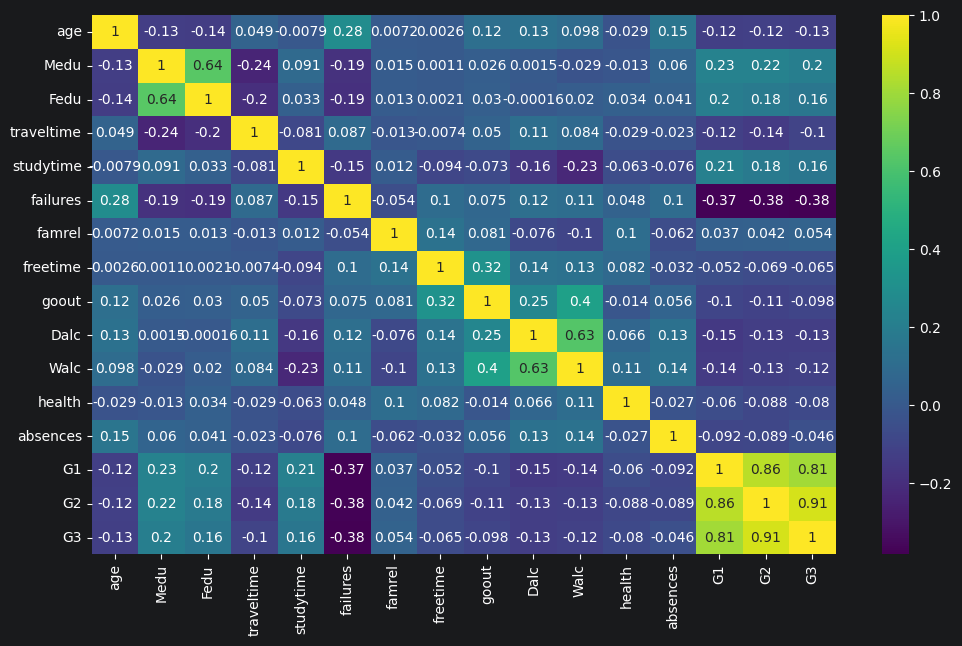

In [18]:
# Matriz de correlacion
plt.figure(figsize=(12,7))
sns.heatmap(df.corr(numeric_only = True),annot=True,cmap='viridis')

In [19]:
# Mostrar categoricas para transformar
df.select_dtypes(include='object').columns

C:\Users\fabia\AppData\Local\Temp\ipykernel_18208\59492462.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'subject'],
      dtype='str')

In [20]:
# Variables para transformar
categoricas = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic', 'subject']

dummies = pd.get_dummies(df[categoricas],drop_first=True)

df_post = pd.concat([df,dummies],axis=1)
df_post = df_post.drop(categoricas, axis=1)
df_post.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 43 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 1044 non-null   int64
 1   Medu                1044 non-null   int64
 2   Fedu                1044 non-null   int64
 3   traveltime          1044 non-null   int64
 4   studytime           1044 non-null   int64
 5   failures            1044 non-null   int64
 6   famrel              1044 non-null   int64
 7   freetime            1044 non-null   int64
 8   goout               1044 non-null   int64
 9   Dalc                1044 non-null   int64
 10  Walc                1044 non-null   int64
 11  health              1044 non-null   int64
 12  absences            1044 non-null   int64
 13  G1                  1044 non-null   int64
 14  G2                  1044 non-null   int64
 15  G3                  1044 non-null   int64
 16  school_MS           1044 non-null   bool 
 17  sex_M 

In [21]:
# Muchos valores son booleanos entonces hay que convertir a INT para la regresion
# Código de Claude
bool_cols = df_post.select_dtypes(include='bool').columns
df_post[bool_cols] = df_post[bool_cols].astype(int)

# Solo se transformaron los booleanos a enteros con el .astype(int)
# Verificamos
print(df_post.dtypes.value_counts())

int64    43
Name: count, dtype: int64


X y Y / Train y Test SplitData

In [22]:
X = df_post.drop(columns=['G3'])

In [23]:
y = df_post['G3'] # Aislamos la variable objetivo G3

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [26]:
X_train.shape

(835, 42)

In [27]:
X_test.shape

(209, 42)

Escalado

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [29]:
X_train

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,subject_portuguese
399,16,3,3,1,2,0,4,3,2,1,...,0,0,1,0,0,1,1,0,0,1
8,15,3,2,1,2,0,4,2,2,1,...,0,0,1,1,0,1,1,1,0,0
400,16,4,3,1,2,0,5,4,2,1,...,0,0,1,0,1,1,1,1,0,1
631,16,2,3,1,2,0,2,3,1,1,...,0,1,0,0,0,1,1,1,0,1
367,17,1,1,3,1,1,5,2,1,1,...,0,0,1,1,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,16,2,2,1,2,0,4,3,5,2,...,0,0,0,0,0,1,0,1,0,1
973,17,3,3,2,2,1,4,5,4,2,...,0,0,1,0,0,1,1,1,0,1
75,15,4,3,1,2,0,4,3,3,2,...,0,0,1,1,1,1,1,1,0,0
599,16,2,3,1,2,0,4,3,3,1,...,0,0,0,0,0,1,1,1,0,1


In [30]:
X_train= scaler.fit_transform(X_train)

In [31]:
X_train

array([[0.14285714, 0.75      , 0.75      , ..., 0.        , 0.        ,
        1.        ],
       [0.        , 0.75      , 0.5       , ..., 1.        , 0.        ,
        0.        ],
       [0.14285714, 1.        , 0.75      , ..., 1.        , 0.        ,
        1.        ],
       ...,
       [0.        , 1.        , 0.75      , ..., 1.        , 0.        ,
        0.        ],
       [0.14285714, 0.5       , 0.75      , ..., 1.        , 0.        ,
        1.        ],
       [0.        , 0.5       , 0.5       , ..., 0.        , 0.        ,
        1.        ]], shape=(835, 42))

In [32]:
X_test = scaler.transform(X_test)

In [33]:
X_train.shape

(835, 42)

In [34]:
X_test.shape

(209, 42)

Creación del modelo

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam

In [38]:
model = Sequential()

# Numero de neuronas
num_neuronas = X_train.shape[1]

model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(num_neuronas,activation='relu'))
model.add(Dense(1)) # 1 sola neurona de salida G3

model.compile(optimizer='adam',loss='mse')


Entrenamiento del modelo

In [39]:
model.fit(x=X_train,y=y_train.values,
          validation_data=(X_test,y_test.values), #si indicamos validation_data en cada epoch calcula sobre el conjunto de test el resultado de pérdidas
          batch_size=32,epochs=25) #batch_size es el tamaño de datos que toma en cada cálculo (indicar potencia de 2) / epochs es el número de iteraciones sobre la red neuronal para ajustar los pesos (w) y bias (b)

Epoch 1/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 133.7346 - val_loss: 87.4730
Epoch 2/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45.2479 - val_loss: 26.0643
Epoch 3/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.5205 - val_loss: 18.7990
Epoch 4/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.6696 - val_loss: 17.0329
Epoch 5/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.4329 - val_loss: 15.6457
Epoch 6/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.1022 - val_loss: 14.0630
Epoch 7/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.0232 - val_loss: 12.6705
Epoch 8/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.5968 - val_loss: 11.8753
Epoch 9/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.2273 - val_loss: 10.4846
Epoch 10/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1081 - val_loss: 8.6913
Epoch 11/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1156 - val_loss: 8.1246
Epoch 12/25
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss

In [40]:
losses = pd.DataFrame(model.history.history)# perdidas de muestro modelo(loss) y el de test(val_loss)

In [41]:
losses

,loss,val_loss
0,133.734573,87.473038
1,45.247852,26.064291
2,16.520489,18.798981
3,14.669646,17.032877
4,13.432859,15.645706
5,12.102233,14.063046
6,11.023157,12.670464
7,9.596785,11.875307
8,8.227295,10.484561
9,7.108148,8.691325


<Axes: >

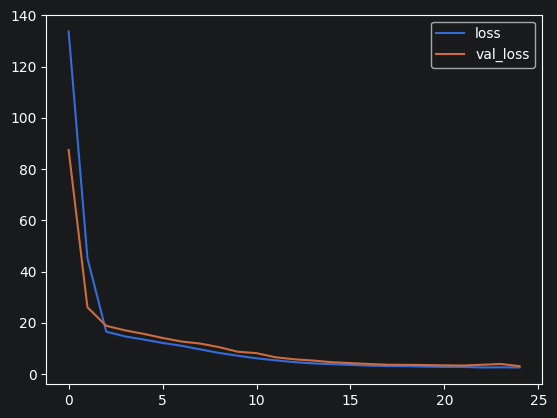

In [42]:
losses.plot()

Evaluacion del modelo
https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics


In [43]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,explained_variance_score, r2_score

In [44]:
X_test

array([[0.14285714, 0.75      , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.28571429, 1.        , 0.75      , ..., 1.        , 1.        ,
        0.        ],
       [0.14285714, 0.5       , 0.25      , ..., 1.        , 1.        ,
        1.        ],
       ...,
       [0.42857143, 1.        , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [0.42857143, 0.25      , 0.75      , ..., 1.        , 1.        ,
        0.        ],
       [0.28571429, 0.75      , 0.75      , ..., 1.        , 0.        ,
        1.        ]], shape=(209, 42))

In [45]:
predictions = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [46]:
# Metricas
mae = mean_absolute_error(y_test,predictions)
rmse = np.sqrt(mean_squared_error(y_test,predictions))
r2 = r2_score(y_test,predictions)
evs = explained_variance_score(y_test,predictions)

print(evs)
print(mae)
print(rmse)
print(r2)

0.8130855560302734
1.1532832384109497
1.7494567300308528
0.812912106513977


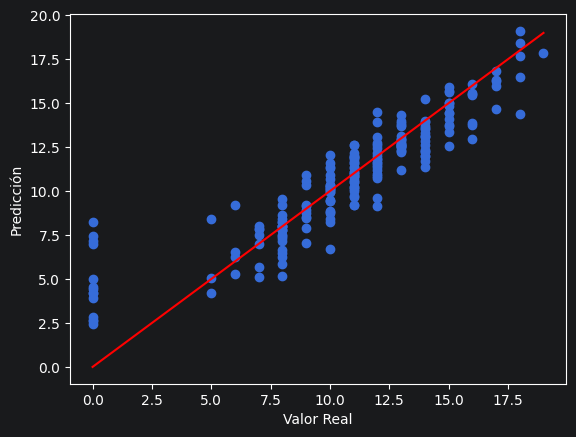

In [47]:
# Visualizar nuestra predicción
plt.scatter(y_test,predictions)
plt.xlabel("Valor Real")
plt.ylabel("Predicción")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.show()

In [48]:
errors = y_test.values.reshape(y_test.shape[0], 1) - predictions #rotar y_test para poder comparar con predictions

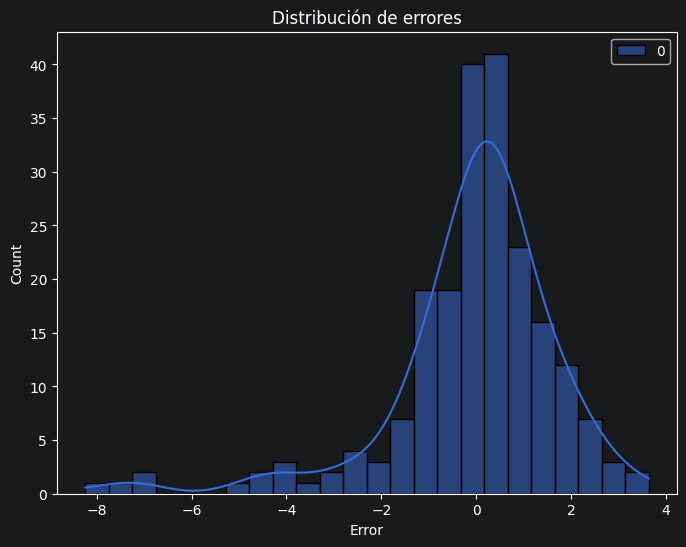

In [49]:
plt.figure(figsize=(8,6))

sns.histplot(errors, kde=True)

plt.xlabel("Error")
plt.title("Distribución de errores")

plt.show()

In [52]:
# Compara Real vs Prediccion
# Codigo Claude
y_pred = model.predict(X_test).flatten()  # .flatten() convierte de [[x],[x]] a [x,x]

resultados = pd.DataFrame({
    'G3 Real':     y_test.values,
    'G3 Predicho': y_pred.round(2)  # Redondear a 2 decimales
})

resultados

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,G3 Real,G3 Predicho
0,11,10.99
1,13,12.81
2,16,15.49
3,11,10.54
4,10,10.07
...,...,...
204,14,13.08
205,12,12.46
206,11,10.23
207,8,5.83


In [53]:
# Variables para la API
print(X.shape)
print(X.columns.tolist())

(1044, 42)
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes', 'subject_portuguese']


Guardar el modelo

In [109]:
model.save(r'C:\Users\fabia\Documents\GitHub\Prediccion-rendimiento-academico\MODELS\model1.h5')